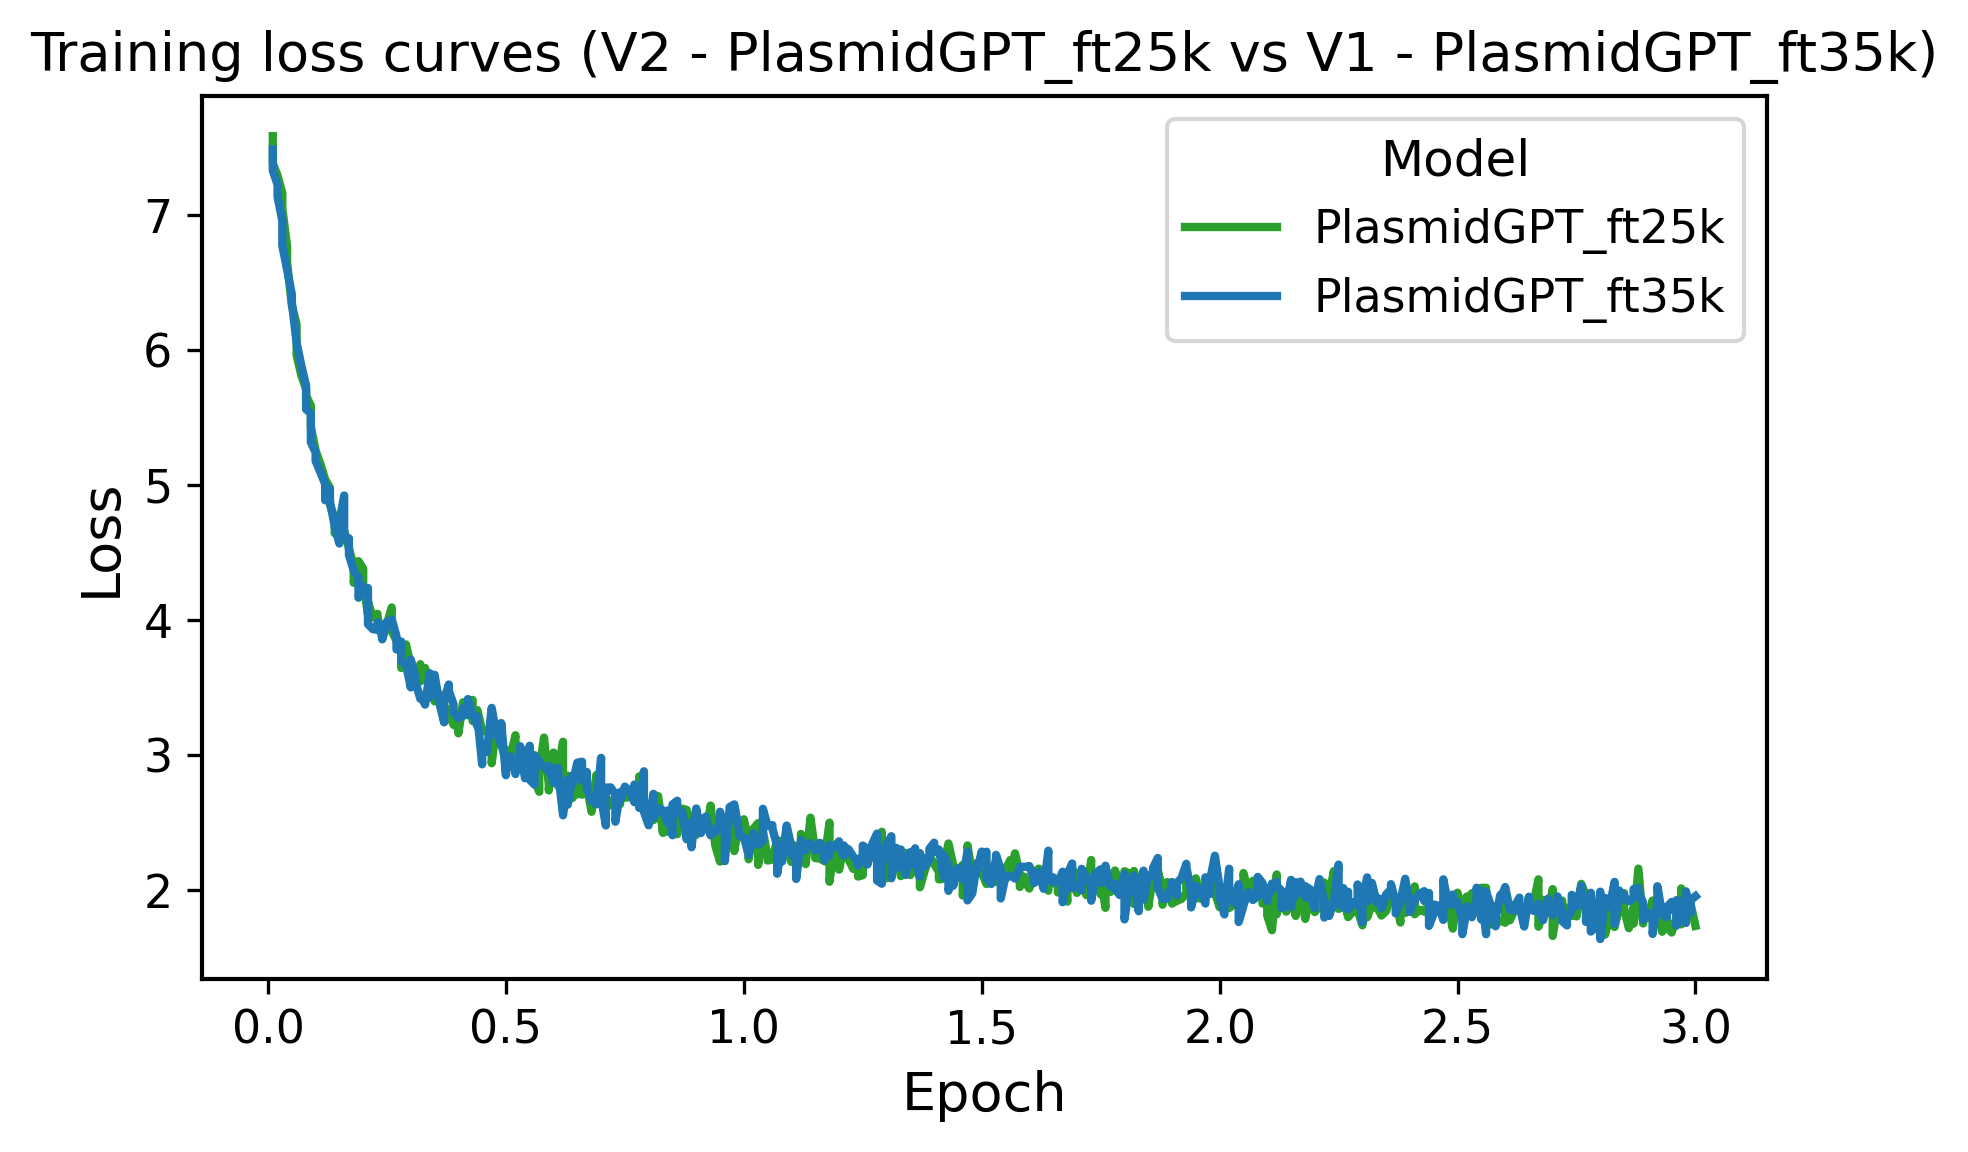

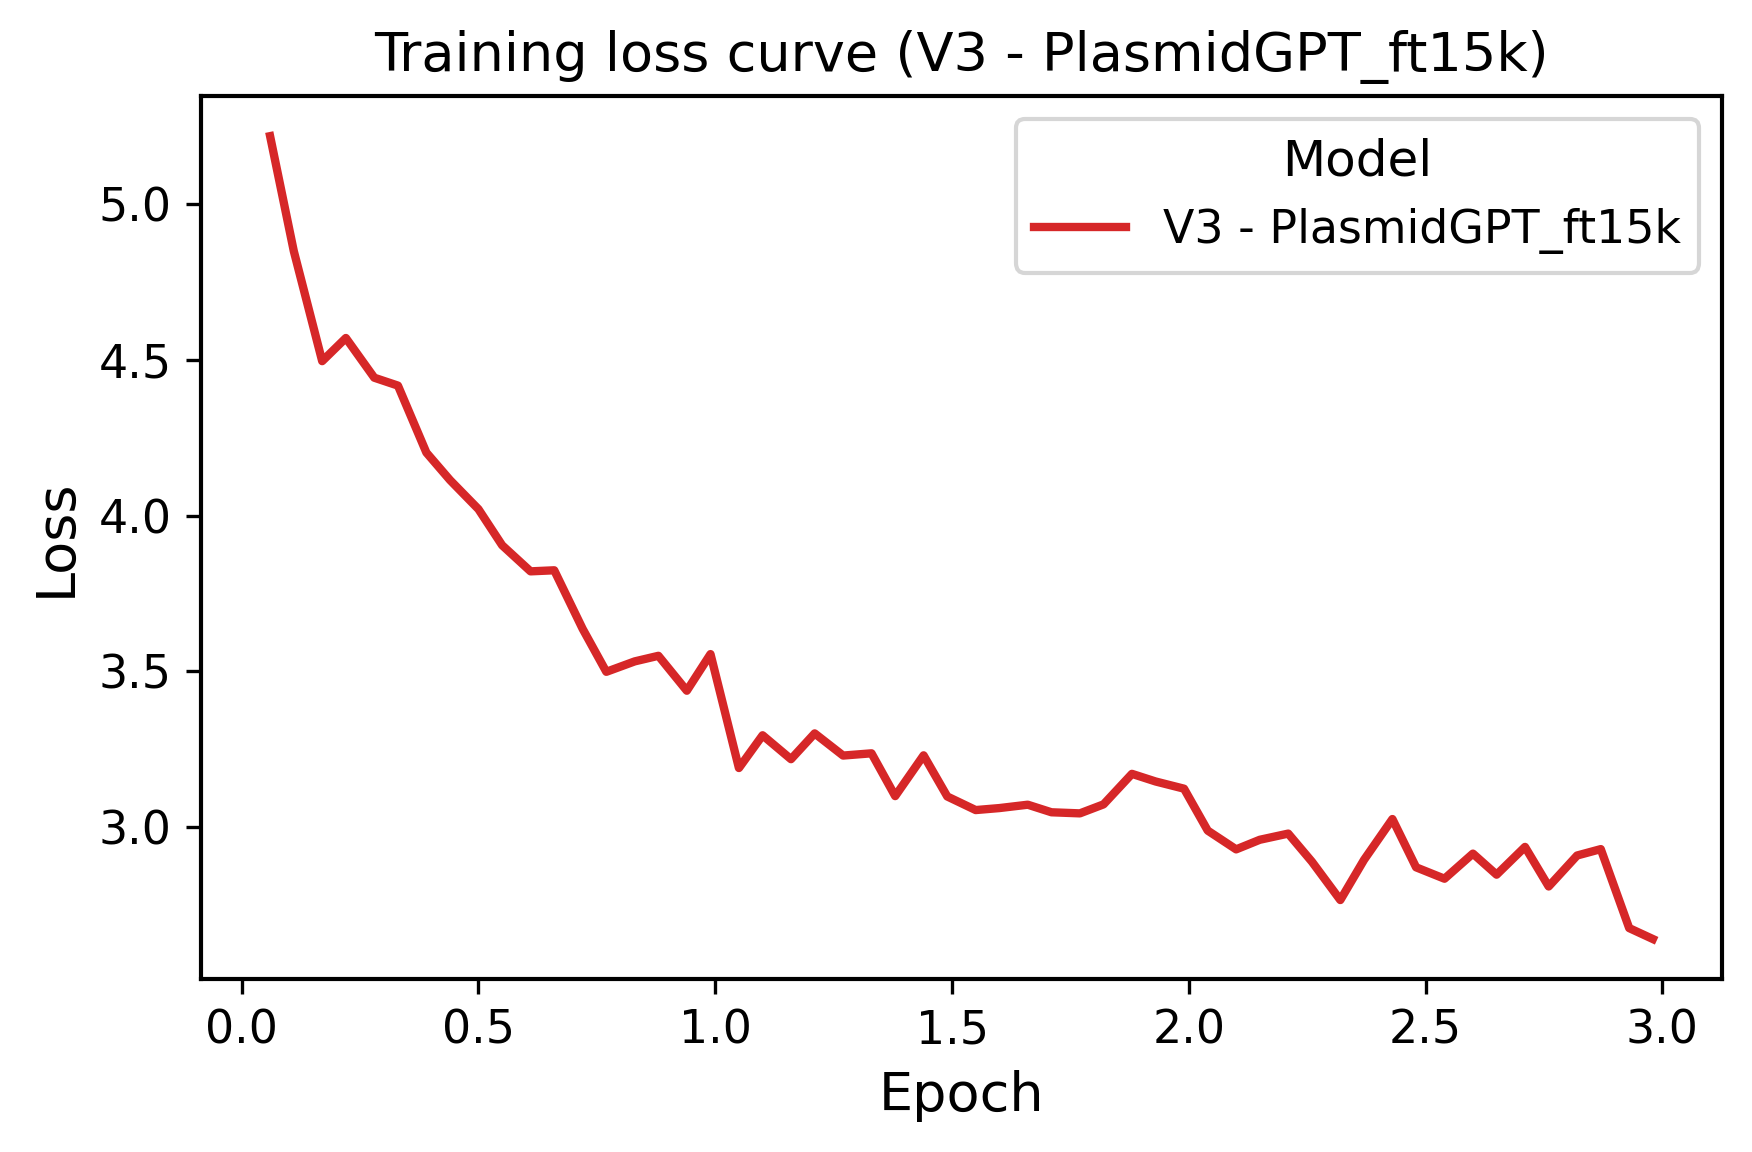

In [3]:
import ast, re
import matplotlib.pyplot as plt
from pathlib import Path

# ─── File paths ─────────────────────────────────────
LOG_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/training_logs")
files = {
    "PlasmidGPT_ft15k": LOG_DIR/"log15k.txt",
    "PlasmidGPT_ft25k": LOG_DIR/"log25k.txt",
    "PlasmidGPT_ft35k": LOG_DIR/"log35k.txt"
}

# ─── Helper to parse logs ───────────────────────────
def parse_log(path):
    raw_entries = []
    with open(path, "r") as f:
        for line in f:
            for chunk in re.findall(r"\{[^}]*\}", line):
                raw_entries.append(chunk)

    data = []
    for s in raw_entries:
        try:
            entry = ast.literal_eval(s)
        except (ValueError, SyntaxError):
            entry = eval(s)
        data.append(entry)

    epochs = [d["epoch"] for d in data]
    losses = [d["loss"] for d in data]
    lrs    = [d["learning_rate"] for d in data]
    return epochs, losses, lrs

# ─── Parse logs ─────────────────────────────────────
curves = {name: parse_log(path) for name, path in files.items()}

# ─── Styling ────────────────────────────────────────
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

palette = {
    "PlasmidGPT_ft15k": "#d62728",  # red
    "PlasmidGPT_ft25k": "#2ca02c",  # green
    "PlasmidGPT_ft35k": "#1f77b4",  # blue
}

OUT = Path("figures")
OUT.mkdir(parents=True, exist_ok=True)

# ─── Figure A: Combined 25k + 35k ──────────────────
fig, ax = plt.subplots(figsize=(6,4))
for name in ["PlasmidGPT_ft25k", "PlasmidGPT_ft35k"]:
    epochs, losses, _ = curves[name]
    ax.plot(epochs, losses, label=name, color=palette[name], lw=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss curves (V2 - PlasmidGPT_ft25k vs V1 - PlasmidGPT_ft35k)")
ax.legend(title="Model")
fig.tight_layout()
plt.show()
fig.savefig(OUT/"loss_PlasmidGPT_ft25k_vs_ft35k.pdf", bbox_inches="tight")

# ─── Figure B: Standalone 15k ───────────────────────
fig, ax = plt.subplots(figsize=(6,4))
epochs, losses, _ = curves["PlasmidGPT_ft15k"]
ax.plot(epochs, losses, label="V3 - PlasmidGPT_ft15k", color=palette["PlasmidGPT_ft15k"], lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss curve (V3 - PlasmidGPT_ft15k)")
ax.legend(title="Model")
fig.tight_layout()
plt.show()
fig.savefig(OUT/"loss_PlasmidGPT_ft15k.pdf", bbox_inches="tight")
